In [14]:
import pandas as pd
import numpy as np
import scipy as sci
import matplotlib.pyplot as plt
import rustworkx as rwx
import time
import re
import os

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import MessagePassing

notebook_start_time = time.time()

In [15]:
min_size = 200


num_qns = 7
skip_lines = 0
trans_file = 'Experimental Data/CO2/transitions_728.txt'
ref_file = 'Experimental Data/CO2/EnergyLevels_728.txt'
segment_file = 'Experimental Data/CO2/segment_master.txt'
output_file = 'Energy_Levels_CO2_728_V10.csv'


In [16]:
def build_R(initial_idx, final_idx):
    num_values = len(initial_idx)
    
    sparse_data = np.empty(num_values * 2)
    sparse_data[0::2] = -1.0
    sparse_data[1::2] = 1.0

    row_indices = np.repeat(np.arange(num_values), 2)

    col_indices = np.empty(num_values * 2, dtype=int)
    col_indices[0::2] = initial_idx
    col_indices[1::2] = final_idx

    R = sci.sparse.csr_matrix((sparse_data, (row_indices, col_indices)))    

    return R

In [17]:
def solve_wls_system(R, W, Y):

    active_cols = np.where(R.getnnz(axis=0) > 0)[0]
    if len(active_cols) == 0:
        return np.full(R.shape[1], np.nan)
    baseline_idx = active_cols[0]
    reduced_cols = active_cols[1:]
    
    if len(reduced_cols) == 0:
        X_full = np.full(R.shape[1], np.nan)
        X_full[baseline_idx] = 0.0
        return X_full
        
    R_reduced = R[:, reduced_cols]

    LHS = R_reduced.T @ W @ R_reduced
    RHS = R_reduced.T @ (W @ Y)
    X_reduced = sci.sparse.linalg.spsolve(LHS, RHS)

    X_full = np.full(R.shape[1], np.nan)
    X_full[baseline_idx] = 0.0
    X_full[reduced_cols] = X_reduced

    X_full[active_cols] -= X_full[baseline_idx]
    return X_full

In [18]:
def propagate_errors(graph, root):
    
    path_variances = rwx.dijkstra_shortest_path_lengths(
        graph, 
        root, 
        edge_cost_fn=lambda weight: float(weight)
    )
    
    propagated_errors = {
        node: np.sqrt(variance) 
        for node, variance in path_variances.items()
    }
    
    return propagated_errors

In [19]:
def get_unit_factor(tag_val, segments=None):
    if segments is None:
        return 1.0
    tag_name = str(tag_val).split('.')[0] if pd.notna(tag_val) else ''
    unit = segments.get(tag_name, 'cm-1')
    if unit == 'MHz':
        return 1e6 / 2.99792458e10
    elif unit == 'GHz':
        return 1e9 / 2.99792458e10
    elif unit == 'THz':
        return 1e12 / 2.99792458e10
    elif unit == 'kHz':
        return 1e3 / 2.99792458e10
    elif unit == 'Hz':
        return 1.0 / 2.99792458e10
    return 1.0

In [20]:
def parse_marvel_line(line, segment_map=None, num_qns=None):
    tokens = line.strip().split()
    if not tokens or line.startswith('#') or '&' in line:
        return None

    tag_idx = next((i for i, tok in enumerate(tokens) if re.search(r'[a-zA-Z].*\.[a-zA-Z0-9_-]+[?]?$', tok)), None)
    if tag_idx is None:
        return None
    tag = tokens[tag_idx]

    data = tokens[:tag_idx]
    iso, name, idx = None, None, 0

    if idx < len(data) and re.match(r'^\d+[a-zA-Z]+', data[idx]):
        iso = data[idx]
        idx += 1

    if idx < len(data) and data[idx].isdigit():
        name = int(data[idx])
        idx += 1


    if (num_qns is None or num_qns == 6) and len(data) - idx >= 17 and data[-1].lower() in ('e', 'f') and data[-8].lower() in ('e', 'f'):
        num_qns = 7

    if num_qns is not None and len(data) - idx >= 2 * num_qns:
        qn_start = len(data) - 2 * num_qns
        num_tokens = data[idx:qn_start]
        upper_qn = data[qn_start:qn_start + num_qns]
        lower_qn = data[qn_start + num_qns:]
        try:
            v = float(num_tokens[0])
            e_v = float(num_tokens[1]) if len(num_tokens) > 1 else 0.0
        except (ValueError, IndexError):
            return None
    else:
        floats, qns = [], []
        for tok in data[idx:]:
            if '.' in tok or 'e' in tok.lower():
                try:
                    floats.append(float(tok))
                    continue
                except ValueError:
                    pass
            qns.append(tok)

        if len(floats) < 2:
            return None

        v = floats[0]
        e_v = floats[1]
        half = len(qns) // 2
        upper_qn = qns[:half]
        lower_qn = qns[half:]

    v = abs(v)
    e_v = abs(e_v)

    if segment_map and tag:
        tag_base = tag.split('.')[0]
        unit_str = segment_map.get(tag_base, 'cm-1')
        factor = {'MHz': 1e6/2.99792458e10, 'GHz': 1e9/2.99792458e10, 'THz': 1e12/2.99792458e10, 'kHz': 1e3/2.99792458e10, 'Hz': 1/2.99792458e10}.get(unit_str, 1.0)
        v *= factor
        e_v *= factor

    return {
        'Isotopologue': iso,
        'Name': name,
        'v': v,
        'e_v': e_v,
        'upper_qn': upper_qn,
        'lower_qn': lower_qn,
        'Tag': tag
    }

def parse_file(filepath, segment_file=None, skip_lines=0, num_qns=None):
    segment_map = {}
    if segment_file and os.path.exists(segment_file):
        try:
            with open(segment_file, 'r', encoding='utf-8') as sf:
                for line in sf:
                    parts = line.strip().split()
                    if len(parts) >= 2:
                        segment_map[parts[0]] = parts[1]
        except Exception:
            pass

    rows = []
    with open(filepath, 'r', encoding='utf-8') as f:
        for i, line in enumerate(f):
            if i < skip_lines:
                continue
            row = parse_marvel_line(line, segment_map=segment_map, num_qns=num_qns)
            if row:
                rows.append(row)
    return pd.DataFrame(rows)


In [21]:
if ref_file is not None and os.path.exists(ref_file):
    raw_ref = pd.read_csv(ref_file, sep=r'\s+', header=None, comment='#')

    if num_qns < raw_ref.shape[1] - 2:
        try:
            float(raw_ref.iloc[0, num_qns])
        except (ValueError, TypeError):
            if raw_ref.shape[1] >= 10:
                num_qns = 7

qn_names = [f'q{i+1}' for i in range(num_qns)]
upper_qn_cols = [f"{q}'" for q in qn_names]
lower_qn_cols = [f"{q}''" for q in qn_names]

parsed = parse_file(trans_file, segment_file=segment_file, skip_lines=skip_lines, num_qns=num_qns)

transitions = pd.DataFrame({
    'v': parsed['v'],
    'e_v': parsed['e_v']
})

for i in range(num_qns):
    transitions[upper_qn_cols[i]] = parsed['upper_qn'].apply(lambda x: str(x[i]) if i < len(x) else '0')
    transitions[lower_qn_cols[i]] = parsed['lower_qn'].apply(lambda x: str(x[i]) if i < len(x) else '0')

if ref_file is not None and os.path.exists(ref_file):

    e_col = num_qns if raw_ref.shape[1] > num_qns + 1 else raw_ref.shape[1] - 2
    unc_col = e_col + 1
    marvel_ref = pd.DataFrame({
        'E_marvel': raw_ref.iloc[:, e_col].astype(float),
        'e_E_marvel': raw_ref.iloc[:, unc_col].astype(float)
    })
    for i in range(num_qns):
        marvel_ref[qn_names[i]] = raw_ref.iloc[:, i].astype(str)
    marvel_ref = marvel_ref.sort_values(by=qn_names + ['E_marvel']).drop_duplicates(subset=qn_names, keep='first').reset_index(drop=True)
else:
    marvel_ref = pd.DataFrame(columns=qn_names + ['E_marvel', 'e_E_marvel'])

upper_rename = dict(zip(upper_qn_cols, qn_names))
lower_rename = dict(zip(lower_qn_cols, qn_names))

concat = pd.concat([
    transitions[upper_qn_cols].rename(columns=upper_rename),
    transitions[lower_qn_cols].rename(columns=lower_rename)
])

states = concat.drop_duplicates().reset_index(drop=True)
state_tuples = [tuple(x) for x in states[qn_names].to_numpy()]
state_to_idx = dict(zip(state_tuples, states.index))
idx_to_state = dict(zip(states.index, state_tuples))

initial_tuples = [tuple(x) for x in transitions[lower_qn_cols].to_numpy()]
final_tuples = [tuple(x) for x in transitions[upper_qn_cols].to_numpy()]

transitions['initial_idx'] = [state_to_idx[st] for st in initial_tuples]
transitions['final_idx'] = [state_to_idx[st] for st in final_tuples]
print(f"Parsed {len(transitions):,} transitions across {len(states):,} unique states.")


Parsed 11,339 transitions across 4,546 unique states.


In [22]:


class SpectroConv(MessagePassing):
    def __init__(self, hidden_dim):
        super(SpectroConv, self).__init__(aggr='mean')
        self.msg_mlp = nn.Sequential(
            nn.Linear(2 * hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )
        self.energy_proj = nn.Linear(1, hidden_dim)
        self.update_mlp = nn.Sequential(
            nn.Linear(2 * hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )

    def forward(self, x, edge_index, edge_attr):
        return self.propagate(edge_index, x=x, edge_attr=edge_attr)

    def message(self, x_i, x_j, edge_attr):
        trans_E = edge_attr[:, 0:1]
        state_interaction = self.msg_mlp(torch.cat([x_i, x_j], dim=-1))
        energy_shift = self.energy_proj(trans_E)
        return state_interaction + energy_shift

    def update(self, aggr_out, x):
        new_state = torch.cat([x, aggr_out], dim=-1)
        return self.update_mlp(new_state) + x


class TransitionAnomalyGNN(nn.Module):
    def __init__(self, num_layers=5, hidden_dim=64, num_classes=4):
        super().__init__()
        self.init_node_feature = nn.Parameter(torch.zeros(1, hidden_dim))
        self.convs = nn.ModuleList([SpectroConv(hidden_dim) for _ in range(num_layers)])
        self.node_energy_head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )
        in_dim = (2 * hidden_dim) + 2 + 1
        self.edge_classifier = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, num_classes)
        )

    def forward(self, edge_index, edge_attr, num_nodes=None):
        if num_nodes is None:
            num_nodes = int(edge_index.max().item()) + 1
        h = self.init_node_feature.expand(num_nodes, -1)
        for conv in self.convs:
            h = conv(h, edge_index, edge_attr)
        node_energies = self.node_energy_head(h).squeeze(-1)
        u_nodes = edge_index[0]
        v_nodes = edge_index[1]
        h_u = h[u_nodes]
        h_v = h[v_nodes]
        h_diff = h_v - h_u
        h_diff_abs = torch.abs(h_diff)
        pred_delta_E = node_energies[v_nodes] - node_energies[u_nodes]
        obs_wavenumber = edge_attr[:, 0]
        obs_uncertainty = torch.clamp(edge_attr[:, 1], min=1e-6)
        norm_res = (obs_wavenumber - pred_delta_E) / obs_uncertainty
        log_res = torch.sign(norm_res) * torch.log1p(torch.abs(norm_res))
        res_feat = log_res.unsqueeze(-1)
        edge_features = torch.cat([h_diff, h_diff_abs, edge_attr, res_feat], dim=-1)
        edge_logits = self.edge_classifier(edge_features)
        return edge_logits, node_energies, norm_res

device = 'cuda' if torch.cuda.is_available() else 'cpu'
checkpoint_path = 'marvel_gnn_classifier_v1.pt'

if os.path.exists(checkpoint_path):
    ckpt = torch.load(checkpoint_path, map_location=device, weights_only=False)
    gnn_model = TransitionAnomalyGNN().to(device)
    gnn_model.load_state_dict(ckpt['model_state_dict'])
    gnn_model.eval()
    threshold = float(ckpt.get('best_threshold', 0.9234))
    class_names = ckpt.get('class_names', ['clean', 'qn_shift', 'qn_swap', 'random_relink'])

    n_trans = len(transitions)
    n_nodes = len(state_to_idx)
    src = torch.tensor(transitions['initial_idx'].values, dtype=torch.long)
    dst = torch.tensor(transitions['final_idx'].values, dtype=torch.long)
    edge_index = torch.stack([
        torch.cat([src, dst]),
        torch.cat([dst, src])
    ]).to(device)

    v_t = torch.tensor(transitions['v'].values, dtype=torch.float).unsqueeze(1)
    ev_t = torch.tensor(transitions['e_v'].values, dtype=torch.float).unsqueeze(1)
    fwd_attr = torch.cat([v_t, ev_t], dim=1)
    rev_attr = torch.cat([-v_t, ev_t], dim=1)
    edge_attr = torch.cat([fwd_attr, rev_attr], dim=0).to(device)

    with torch.no_grad():
        edge_logits, _, norm_res = gnn_model(edge_index, edge_attr, num_nodes=n_nodes)
        fwd_logits = edge_logits[:n_trans]
        fwd_residuals = norm_res[:n_trans].cpu().numpy()
        if 'log_class_weights' in ckpt:
            log_w = torch.tensor(ckpt['log_class_weights'], device=device)
            cal_logits = fwd_logits - log_w
            probs = F.softmax(cal_logits, dim=-1).cpu().numpy()
        else:
            probs = F.softmax(fwd_logits, dim=-1).cpu().numpy()
        anomaly_probs = 1.0 - probs[:, 0]
        pred_classes = np.argmax(probs, axis=-1)

    flagged_mask = (anomaly_probs >= threshold)
    flagged_count = int(np.sum(flagged_mask))
    shift_count = int(np.sum(flagged_mask & (pred_classes == 1)))
    swap_count = int(np.sum(flagged_mask & (pred_classes == 2)))
    relink_count = int(np.sum(flagged_mask & (pred_classes == 3)))

    print("=" * 55)
    print("         GNN TRANSITION MASKING STATISTICS       ")
    print("=" * 55)
    print(f"Device: {device} | Threshold: {threshold:.4f}")
    print(f"Total Transitions Parsed : {n_trans:,}")
    print(f"Flagged Bad Transitions  : {flagged_count:,} ({(flagged_count/n_trans)*100:.2f}%)")
    print(f"  - QN Shift Errors      : {shift_count:,}")
    print(f"  - QN Swap Errors       : {swap_count:,}")
    print(f"  - Random Relink/Outlier: {relink_count:,}")
    print(f"Clean Transitions Kept   : {n_trans - flagged_count:,} ({(1 - flagged_count/n_trans)*100:.2f}%)")
    print("=" * 55 + "\n")

    top_k = n_trans
    top_indices = np.argsort(-anomaly_probs)[:top_k]

    src_arr = transitions['initial_idx'].values
    dst_arr = transitions['final_idx'].values
    wavenumbers = transitions['v'].values
    uncertainties = transitions['e_v'].values

    print(f"  Top {top_k} Highest Anomaly Transitions with Predicted Diagnosis & Residuals:")
    print(f"  {'Rank':<5} {'Trans Idx':<10} {'From ID':<9} {'To ID':<9} {'Wavenumber':<16} {'Uncertainty':<14} {'|Res/unc|':<14} {'Anomaly P':<11} {'Predicted Diagnosis':<20} {'Conf':<8}")
    for rank, idx in enumerate(top_indices, 1):
        u_idx, v_idx = src_arr[idx], dst_arr[idx]
        wn = wavenumbers[idx]
        unc = uncertainties[idx]
        res_val = abs(float(fwd_residuals[idx]))
        p_anom = anomaly_probs[idx]

        corrupt_p = probs[idx, 1:]
        pred_diag_idx = np.argmax(corrupt_p) + 1
        pred_diag_name = class_names[pred_diag_idx]
        pred_diag_conf = corrupt_p[pred_diag_idx - 1]

        print(f"  {rank:<5} {idx:<10} {u_idx:<9} {v_idx:<9} {wn:<16.6f} {unc:<14.2e} {res_val:<14.2f} {p_anom:<11.4f} {pred_diag_name:<20} {pred_diag_conf:<8.4f}")
    print()

    transitions['is_bad'] = flagged_mask
    transitions['anomaly_prob'] = anomaly_probs
    transitions['predicted_diagnosis'] = [class_names[c] for c in pred_classes]
    transitions = transitions[~transitions['is_bad']].reset_index(drop=True)
else:
    print(f"Checkpoint {checkpoint_path} not found. Running without masking.")

         GNN TRANSITION MASKING STATISTICS       
Device: cuda | Threshold: 0.9234
Total Transitions Parsed : 11,339
Flagged Bad Transitions  : 134 (1.18%)
  - QN Shift Errors      : 0
  - QN Swap Errors       : 1
  - Random Relink/Outlier: 133
Clean Transitions Kept   : 11,205 (98.82%)

  Top 11339 Highest Anomaly Transitions with Predicted Diagnosis & Residuals:
  Rank  Trans Idx  From ID   To ID     Wavenumber       Uncertainty    |Res/unc|      Anomaly P   Predicted Diagnosis  Conf    
  1     77         4106      44        692.646000       3.00e-03       196825.84      0.9903      random_relink        0.9578  
  2     41         4146      41        657.569000       3.00e-03       182591.92      0.9894      random_relink        0.9623  
  3     75         4108      1         691.147000       3.00e-03       187363.94      0.9884      random_relink        0.9588  
  4     8          4113      8         633.857000       3.00e-03       174734.19      0.9883      random_relink        0.

In [23]:
G = rwx.PyGraph(multigraph=True)
G.add_nodes_from(range(len(state_to_idx)))
    
dijkstra_weights = transitions['e_v'].to_numpy()**2
    
edges = list(zip(transitions['initial_idx'], transitions['final_idx'], dijkstra_weights))
G.add_edges_from(edges)

components = rwx.connected_components(G)
filtered_components = {comp_id: nodes for comp_id, nodes in enumerate(components) if len(nodes) >= min_size}

node_to_comp = {node: comp_id for comp_id, nodes in filtered_components.items() for node in nodes}
transitions['Component'] = transitions['initial_idx'].map(node_to_comp)

## Graph checking

In [24]:
print(f"Nodes: {G.num_nodes()}")
print(f"Edges: {G.num_edges()}")
print(f"Multigraph: {G.multigraph}")
print(f"Connected:   : {rwx.is_connected(G)}")
print(f"Component num: {rwx.number_connected_components(G)}")
print(f"valid_num    : {len(filtered_components)}")

cut_nodes = rwx.articulation_points(G)
print(f"Articulation points : {len(cut_nodes)}")

Nodes: 4546
Edges: 11205
Multigraph: True
Connected:   : False
Component num: 72
valid_num    : 1
Articulation points : 421


In [25]:
results = []
mapped_data = []

valid_transitions = transitions.dropna(subset=['Component'])

if 'E_marvel' in marvel_ref.columns and not marvel_ref.empty:
    ground_row = marvel_ref.loc[marvel_ref['E_marvel'].idxmin()]
    ground_state_tuple = tuple(ground_row[qn_names])
else:
    ground_state_tuple = tuple([0] * num_qns)

for comp_id, group in valid_transitions.groupby('Component'):
    comp_id = int(comp_id)
    
    Y_local = np.abs(group['v'].values)
    Y_unc_local = group['e_v'].values
    local_initial_idx = group['initial_idx'].values
    local_final_idx = group['final_idx'].values

    R_local = build_R(local_initial_idx, local_final_idx)
    local_weights = 1 / (Y_unc_local ** 2)
    W_local = sci.sparse.diags(local_weights)

    result = solve_wls_system(R_local, W_local, Y_local)
    
    ground_idx = state_to_idx.get(ground_state_tuple)
    if ground_idx is not None and ground_idx < len(result) and not np.isnan(result[ground_idx]):
        result -= result[ground_idx]
        
    results.append(result)

    comp_nodes = list(filtered_components[comp_id])
    
    if ground_idx is not None and ground_idx in comp_nodes:
        root = ground_idx
    else:
        comp_energies = result[comp_nodes]
        root = comp_nodes[np.nanargmin(comp_energies)]
        
    component_errors = propagate_errors(G, root)

    for idx in comp_nodes:
        if idx < len(result) and not np.isnan(result[idx]):
            st_qns = idx_to_state[idx]
            entry = {'Component': comp_id}
            for q_name, q_val in zip(qn_names, st_qns):
                entry[q_name] = q_val
            entry['Energy'] = result[idx]
            entry['Error'] = component_errors.get(idx, np.nan)
            entry['Num_Transitions'] = G.degree(idx)
            mapped_data.append(entry)

final_energies_df = pd.DataFrame(mapped_data)

if not marvel_ref.empty:
    final_energies_df = final_energies_df.merge(
        marvel_ref[qn_names + ['E_marvel', 'e_E_marvel']], 
        on=qn_names, 
        how='left'
    )
    final_energies_df['Residual'] = final_energies_df['Energy'] - final_energies_df['E_marvel']

    matched_df = final_energies_df.dropna(subset=['Residual'])
    for comp_id, comp_group in final_energies_df.groupby('Component'):
        comp_matched = comp_group.dropna(subset=['Residual'])
        n_matched = len(comp_matched)
        
        if n_matched > 0:
            res = comp_matched['Residual'].values

            if ground_idx is None or ground_idx not in list(filtered_components[comp_id]):
                res = res - np.median(res)
            rmse = np.sqrt(np.mean(res**2))
            mae = np.mean(np.abs(res))
            max_err = np.max(np.abs(res))
            
            print(f"\nComponent {comp_id}:")
            print(f" Calculated: {len(comp_group)}")
            print(f" Matched: {n_matched}")
            print(f" RMS: {rmse:.6e} cm^-1")
            print(f" MAE: {mae:.6e} cm^-1")
            print(f" Max Residual: {max_err:.6e} cm^-1\n")
        else:
            print(f"Floating Component {comp_id}: {len(comp_group)} levels")
else:
    for comp_id, comp_group in final_energies_df.groupby('Component'):
        print(f"\nComponent {comp_id}: {len(comp_group)} levels")

final_energies_df = final_energies_df.sort_values(by=['Component'] + qn_names).reset_index(drop=True)
final_energies_df.to_csv(output_file, index=False)
print('\nOutput saved to ' + output_file)


Component 0:
 Calculated: 4316
 Matched: 4316
 RMS: 6.399643e-04 cm^-1
 MAE: 4.600264e-04 cm^-1
 Max Residual: 3.660689e-03 cm^-1


Output saved to Energy_Levels_CO2_728_V10.csv


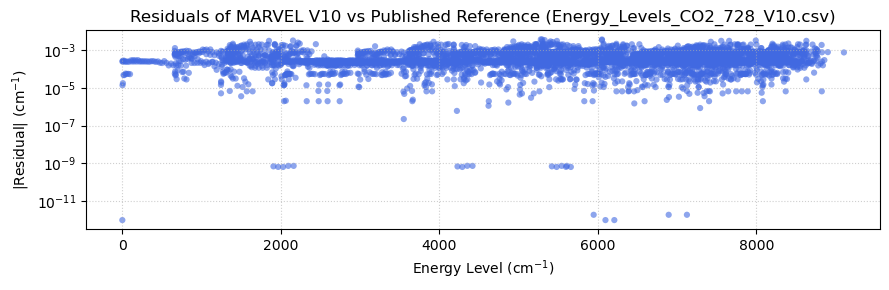

In [26]:
if not marvel_ref.empty and 'Residual' in final_energies_df.columns:
    matched_df = final_energies_df.dropna(subset=['Residual'])
    if not matched_df.empty:
        plt.figure(figsize=(9, 3))
        plt.scatter(matched_df['Energy'], np.abs(matched_df['Residual']) + 1e-12, alpha=0.6, edgecolors='none', s=20, color='royalblue')
        plt.xlabel('Energy Level (cm$^{-1}$)')
        plt.ylabel('|Residual| (cm$^{-1}$)')
        plt.yscale('log')
        plt.title(f'Residuals of MARVEL V10 vs Published Reference ({output_file})')
        plt.grid(True, linestyle=':', alpha=0.6)
        plt.tight_layout()
        plt.show()
else:
    print('No reference energies provided, skipping residual plot.')